# Statistics & EDA Lab: Understanding Your Data Before Modeling

## Student Practice Notebook

**Name:** K.Satya Ganesh   
**Register Number:** AP24110010736
**Date:** 28-08-2026   

## Learning Objectives

After completing this lab, you will be able to:

- Compute and interpret descriptive statistics beyond `.describe()` (variance, std, skewness)
- Visualize and identify distribution shapes (normal vs skewed)
- Compute and interpret correlation between features
- Run a basic hypothesis test (t-test) and interpret a p-value
- Understand confidence intervals conceptually
- Apply statistical thinking to image and text data

### Why this week matters
You now have clean, scaled, encoded data. Before building any model, a good data scientist asks: **what does this data actually look like? Which features seem related? Is a difference I'm seeing real, or just noise?** That's what statistics answers.

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Descriptive Statistics Beyond `.describe()`

`.describe()` gives mean, std, min/max, quartiles. Two more measures matter a lot for understanding data shape:

- **Variance / Std Dev**: how spread out the data is
- **Skewness**: whether the data leans left (negative skew) or right (positive skew), or is symmetric (skew ≈ 0)

### Demonstration


In [2]:
print("Mean:", tips['total_bill'].mean())
print("Median:", tips['total_bill'].median())
print("Variance:", tips['total_bill'].var())
print("Std Dev:", tips['total_bill'].std())
print("Skewness:", tips['total_bill'].skew())


Mean: 19.78594262295082
Median: 17.795
Variance: 79.25293861397826
Std Dev: 8.902411954856856
Skewness: 1.1332130376158205


**Reading skewness:**
- Skew ≈ 0 → roughly symmetric
- Skew > 0 → right-skewed (long tail of high values; mean > median)
- Skew < 0 → left-skewed (long tail of low values; mean < median)


### Student Practice

Compute mean, median, variance, std dev, and skewness for the `tip_pct` column. Based on the mean vs median relationship, is it left-skewed, right-skewed, or roughly symmetric? Write your conclusion.


In [3]:
tip_pct_mean = tips['tip_pct'].mean()
tip_pct_median = tips['tip_pct'].median()
tip_pct_variance = tips['tip_pct'].var()
tip_pct_std = tips['tip_pct'].std()
tip_pct_skewness = tips['tip_pct'].skew()

print("Mean:", tip_pct_mean)
print("Median:", tip_pct_median)
print("Variance:", tip_pct_variance)
print("Std Dev:", tip_pct_std)
print("Skewness:", tip_pct_skewness)

if tip_pct_mean > tip_pct_median:
    print("Conclusion: tip_pct is right-skewed.")
elif tip_pct_mean < tip_pct_median:
    print("Conclusion: tip_pct is left-skewed.")
else:
    print("Conclusion: tip_pct is roughly symmetric.")


Mean: 0.16080258172250472
Median: 0.15476977125802577
Variance: 0.003729814124817058
Std Dev: 0.061072204191571944
Skewness: 3.3492170245653594
Conclusion: tip_pct is right-skewed.


**Your answer:** Two columns can have the same mean but very different standard deviations because the values can be spread out differently around that mean. Their skewness can also differ because one distribution may have a long tail while the other is more symmetric. This matters for preprocessing because features with large spread or strong skew may need scaling, transformation, or outlier handling before modeling.

## Part 2: Visualizing Distributions

Numbers alone can be misleading — always look at the shape too.

### Demonstration


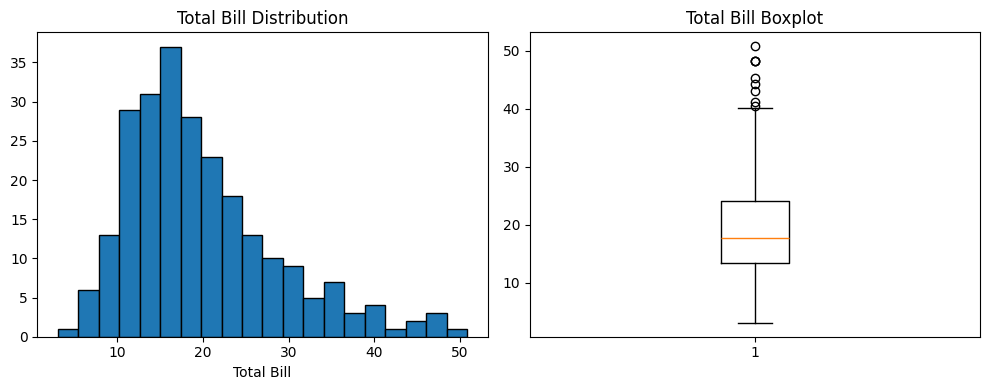

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].hist(tips['total_bill'], bins=20, edgecolor='black')
axes[0].set_title("Total Bill Distribution")
axes[0].set_xlabel("Total Bill")

axes[1].boxplot(tips['total_bill'])
axes[1].set_title("Total Bill Boxplot")

plt.tight_layout()
plt.show()


**Your prediction:** I predict that `tip_pct` will be **skewed rather than perfectly bell-shaped**, because tip percentages can contain some unusually high values.

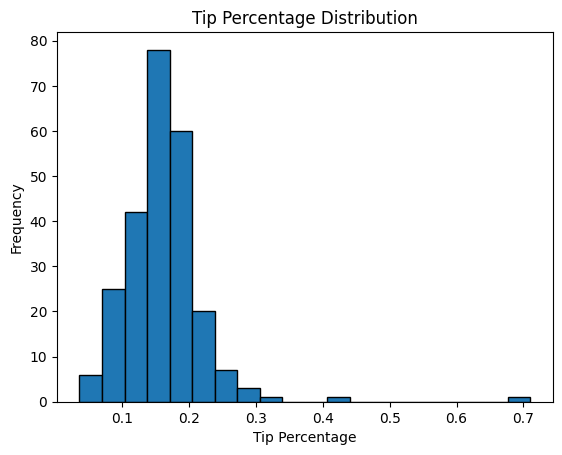

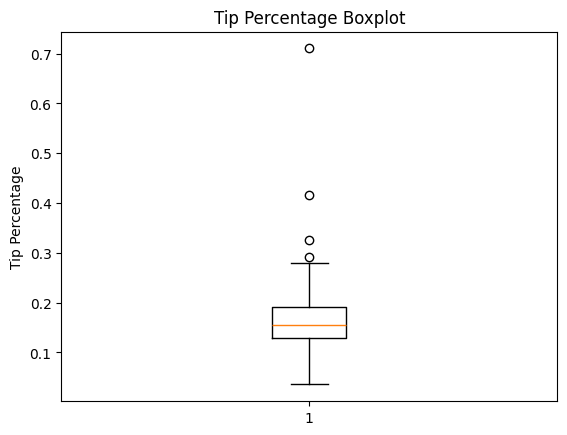

In [5]:
plt.figure()
plt.hist(tips['tip_pct'], bins=20, edgecolor='black')
plt.title("Tip Percentage Distribution")
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(tips['tip_pct'])
plt.title("Tip Percentage Boxplot")
plt.ylabel("Tip Percentage")
plt.show()


## Part 3: Correlation

Correlation measures how strongly two numeric variables move together, from -1 (perfectly inverse) to +1 (perfectly aligned). 0 means no linear relationship.

### Demonstration


Correlation between total_bill and tip: 0.676


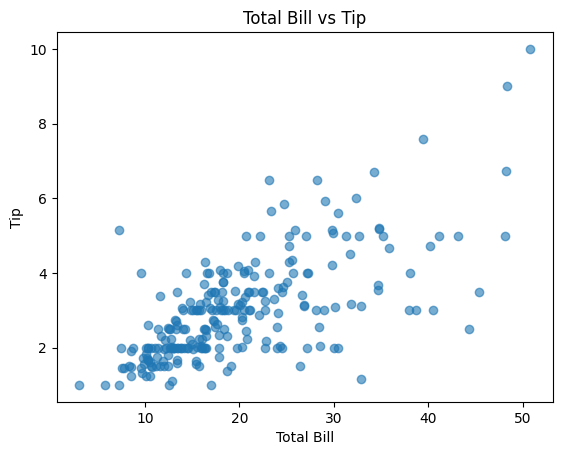

In [6]:
correlation = tips['total_bill'].corr(tips['tip'])
print(f"Correlation between total_bill and tip: {correlation:.3f}")

plt.figure()
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()


In [7]:
# Correlation matrix across all numeric columns
numeric_cols = tips.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
corr_matrix


,total_bill,tip,size,tip_pct
total_bill,1.000,0.676,0.598,-0.339
tip,0.676,1.000,0.489,0.342
size,0.598,0.489,1.000,-0.143
tip_pct,-0.339,0.342,-0.143,1.000


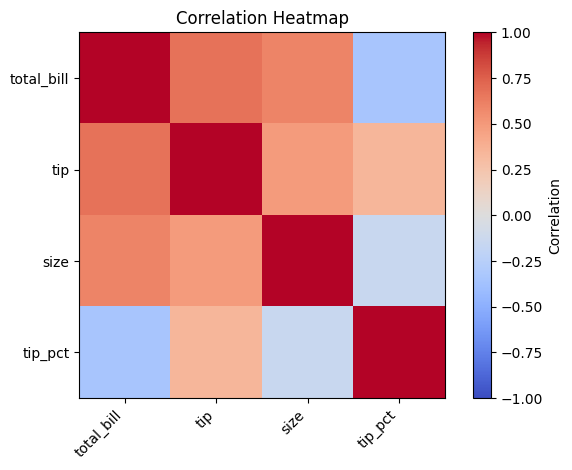

In [8]:
# Visualize as a heatmap
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Your answer:** The correlation between `size` and `total_bill` is expected to be **stronger** than the correlation between `size` and `tip_pct`. Larger parties generally have larger total bills, while party size does not necessarily increase the percentage of the bill given as a tip. This makes sense because `tip_pct` is already normalized by `total_bill`.

In [9]:
size_total_bill_corr = tips['size'].corr(tips['total_bill'])
size_tip_pct_corr = tips['size'].corr(tips['tip_pct'])

print(f"Correlation between size and total_bill: {size_total_bill_corr:.3f}")
print(f"Correlation between size and tip_pct: {size_tip_pct_corr:.3f}")

def strength(r):
    a = abs(r)
    if a < 0.3:
        return "weak"
    elif a < 0.7:
        return "moderate"
    else:
        return "strong"

print("size vs total_bill:", strength(size_total_bill_corr))
print("size vs tip_pct:", strength(size_tip_pct_corr))

if abs(size_total_bill_corr) > abs(size_tip_pct_corr):
    print("The stronger relationship is size vs total_bill.")
else:
    print("The stronger relationship is size vs tip_pct.")


Correlation between size and total_bill: 0.598
Correlation between size and tip_pct: -0.143
size vs total_bill: moderate
size vs tip_pct: weak
The stronger relationship is size vs total_bill.


**Your answer:** Yes. Two variables can have a strong relationship that is curved rather than linear. Pearson correlation measures linear association, so a U-shaped or other symmetric curved relationship can have a correlation near 0 even though one variable clearly depends on the other.

## Part 4: Hypothesis Testing — Is a Difference Real?

You've seen group averages differ (e.g. average tip_pct by day). But is that difference **statistically significant**, or could it just be random variation? A **t-test** compares two group means and gives a **p-value**: the probability of seeing a difference this large (or larger) if there were truly no difference.

**Rule of thumb:** if p-value < 0.05, we consider the difference statistically significant.

### Demonstration: do smokers tip a different percentage than non-smokers?


In [10]:
smoker_tips = tips[tips['smoker']=='Yes']['tip_pct']
nonsmoker_tips = tips[tips['smoker']=='No']['tip_pct']

print("Smoker mean tip_pct:", smoker_tips.mean())
print("Non-smoker mean tip_pct:", nonsmoker_tips.mean())

t_stat, p_value = stats.ttest_ind(smoker_tips, nonsmoker_tips)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference")
else:
    print("Result: NOT a statistically significant difference (could be random variation)")


Smoker mean tip_pct: 0.16319604463687792
Non-smoker mean tip_pct: 0.15932846217921523

t-statistic: 0.480
p-value: 0.632
Result: NOT a statistically significant difference (could be random variation)


**Your prediction:** I predict there will **not** be a statistically significant difference in `tip_pct` between Lunch and Dinner at the 0.05 level. The group means may differ, but the difference may be small relative to the variation within the groups.

In [11]:
lunch_tip_pct = tips[tips['time'] == 'Lunch']['tip_pct']
dinner_tip_pct = tips[tips['time'] == 'Dinner']['tip_pct']

print("Lunch mean tip_pct:", lunch_tip_pct.mean())
print("Dinner mean tip_pct:", dinner_tip_pct.mean())

t_stat, p_value = stats.ttest_ind(lunch_tip_pct, dinner_tip_pct)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference")
else:
    print("Result: NOT a statistically significant difference")


Lunch mean tip_pct: 0.164127928162505
Dinner mean tip_pct: 0.15951778877977735
t-statistic: 0.528
p-value: 0.598
Result: NOT a statistically significant difference


**Your answer:** Comparing means alone does not tell us whether the observed difference is large relative to normal variation in the data. A significance test gives evidence about whether a difference could reasonably occur by random sampling variation under the null hypothesis. It helps prevent us from treating every small difference as meaningful.

## Part 5: Confidence Intervals (Conceptual Introduction)

A **confidence interval (CI)** gives a range where we're reasonably confident the true population mean lies, based on our sample. A 95% CI means: if we repeated this sampling process many times, about 95% of such intervals would contain the true mean.

### Demonstration


In [12]:
mean_bill = tips['total_bill'].mean()
sem = stats.sem(tips['total_bill'])  # standard error of the mean
ci = stats.t.interval(0.95, len(tips)-1, loc=mean_bill, scale=sem)

print(f"Sample mean total_bill: {mean_bill:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")


Sample mean total_bill: 19.79
95% Confidence Interval: (18.66, 20.91)


**Your answer:** The 95% confidence interval gives a plausible range for the population's true mean `tip_pct`, based on the sample. If we repeated the same sampling procedure many times, about 95% of the resulting intervals would contain the true population mean.

In [13]:
mean_tip_pct = tips['tip_pct'].mean()
sem_tip_pct = stats.sem(tips['tip_pct'])
ci_tip_pct = stats.t.interval(
    0.95,
    len(tips['tip_pct']) - 1,
    loc=mean_tip_pct,
    scale=sem_tip_pct
)

print(f"Mean tip_pct: {mean_tip_pct:.4f}")
print(f"95% Confidence Interval: ({ci_tip_pct[0]:.4f}, {ci_tip_pct[1]:.4f})")
print(
    f"In plain language: based on this sample, the population's true average tip percentage "
    f"is reasonably expected to lie between {ci_tip_pct[0]:.4f} and {ci_tip_pct[1]:.4f}."
)


Mean tip_pct: 0.1608
95% Confidence Interval: (0.1531, 0.1685)
In plain language: based on this sample, the population's true average tip percentage is reasonably expected to lie between 0.1531 and 0.1685.


# Mini Project A: Statistical Comparison of Images (Image Track)

Using the image metadata DataFrame you built in Week 2 (filename, brightness, RGB averages, etc.), apply statistical thinking to compare your images.

## Step 1: Rebuild your image metadata table


In [14]:
from google.colab import files
uploaded = files.upload()


Saving babu.jpg to babu.jpg


In [15]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
rows = []
for name in filenames:
    arr = np.array(Image.open(name))
    rows.append({
        'filename': name,
        'avg_brightness': np.mean(arr),
        'avg_red': np.mean(arr[:,:,0]) if arr.ndim==3 else np.mean(arr),
        'avg_green': np.mean(arr[:,:,1]) if arr.ndim==3 else np.mean(arr),
        'avg_blue': np.mean(arr[:,:,2]) if arr.ndim==3 else np.mean(arr),
        'height': arr.shape[0],
        'width': arr.shape[1],
    })

image_df = pd.DataFrame(rows)
image_df


,filename,avg_brightness,avg_red,avg_green,avg_blue,height,width
0,babu.jpg,109.94,104.628,116.359,108.832,1918,1080


## Step 2: Statistical analysis

1. Compute the mean, std dev, and skewness of `avg_brightness` across your images.
2. Compute the correlation between `avg_brightness` and `avg_red` (do brighter images tend to have more red?).
3. **If you have at least 2 images you can meaningfully group** (e.g. indoor vs outdoor, or any 2 categories you choose), run a t-test comparing their `avg_brightness`. If you only have very few images, skip the t-test and instead just discuss whether a t-test would even be reliable with so few samples.


In [16]:
print("Mean avg_brightness:", image_df['avg_brightness'].mean())
print("Std dev avg_brightness:", image_df['avg_brightness'].std())
print("Skewness avg_brightness:", image_df['avg_brightness'].skew())

brightness_red_corr = image_df['avg_brightness'].corr(image_df['avg_red'])
print(f"Correlation between avg_brightness and avg_red: {brightness_red_corr:.3f}")

print("\nInterpretation:")
if brightness_red_corr > 0:
    print("The correlation is positive: brighter images tend to have higher average red intensity.")
elif brightness_red_corr < 0:
    print("The correlation is negative: brighter images tend to have lower average red intensity.")
else:
    print("The correlation is near zero: there is little linear relationship.")

print("\nT-test note: with only a few images, a t-test would be unreliable because the sample size is too small to estimate group variability and population differences confidently.")


Mean avg_brightness: 109.9399504692388
Std dev avg_brightness: nan
Skewness avg_brightness: nan
Correlation between avg_brightness and avg_red: nan

Interpretation:
The correlation is near zero: there is little linear relationship.

T-test note: with only a few images, a t-test would be unreliable because the sample size is too small to estimate group variability and population differences confidently.


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


**Your answer:** With only 3–5 images, a t-test is much less reliable than with hundreds of observations. A very small sample gives a poor estimate of the population variability and makes the p-value unstable. With so few images, descriptive statistics and careful discussion are usually more appropriate than strong statistical conclusions.

# Mini Project B: Word Frequency Distribution Analysis (NLP Track)

## Step 1: Build a word frequency table for a longer text

### Demonstration: Zipf's Law preview

A famous finding in linguistics: in most natural language text, word frequency is **highly right-skewed** — a few words (like "the", "a") appear extremely often, and most words appear only once or twice. This is called **Zipf's Law**.


In [17]:
paragraph = (
    "Data science combines statistics and programming. Statistics helps us understand data. "
    "Programming helps us process data. Machine learning is a part of data science. "
    "Data science uses statistics, programming, and machine learning together. "
    "Understanding statistics is essential for data science."
)

tokens = paragraph.lower().replace('.', '').replace(',', '').split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == w) for w in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts}).sort_values('count', ascending=False).reset_index(drop=True)
print(word_freq)
print("\nSkewness of word counts:", word_freq['count'].skew())


             word  count
0            data      6
1         science      4
2      statistics      4
3     programming      3
4             and      2
5              us      2
6              is      2
7        learning      2
8           helps      2
9         machine      2
10      essential      1
11              a      1
12       combines      1
13        process      1
14           part      1
15             of      1
16            for      1
17       together      1
18     understand      1
19  understanding      1
20           uses      1

Skewness of word counts: 1.8510785401434868


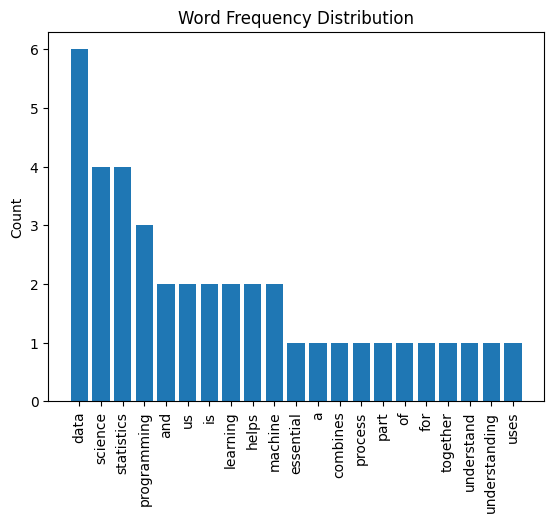

In [18]:
plt.figure()
plt.bar(word_freq['word'], word_freq['count'])
plt.xticks(rotation=90)
plt.title("Word Frequency Distribution")
plt.ylabel("Count")
plt.show()


### Student Practice

1. Pick your own longer paragraph (5+ sentences) and build the same word frequency table.
2. Compute the skewness of the word counts. Is it right-skewed (consistent with Zipf's Law)?
3. What percentage of words in your vocabulary appear only once? (This is usually a large percentage — that's Zipf's Law in action.)


             word  count
0              to      3
1            data      3
2             and      2
3      statistics      2
4              us      2
5            uses      2
6           helps      2
7            also      1
8             are      1
9         analyze      1
10         decide      1
11          build      1
12             in      1
13    information      1
14       learning      1
15        machine      1
16    differences      1
17       discover      1
18         easier      1
19           good      1
20         models      1
21          model      1
22     meaningful      1
23          makes      1
24  preprocessing      1
25     predictive      1
26       observed      1
27       patterns      1
28  relationships      1
29        science      1
30     understand      1
31         trends      1
32        unusual      1
33         values      1
34  visualization      1
35        whether      1

Skewness of word counts: 2.199328576269819
Percentage of vocabulary appear

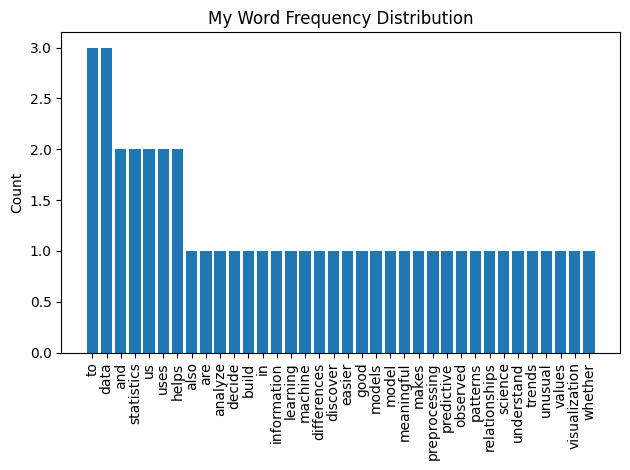

In [19]:
my_paragraph = (
    "Data science uses statistics to understand patterns in information. "
    "Machine learning uses data to build predictive models. "
    "Good preprocessing makes data easier to analyze and model. "
    "Visualization helps us discover trends, unusual values, and relationships. "
    "Statistics also helps us decide whether observed differences are meaningful."
)

my_tokens = my_paragraph.lower().replace('.', '').replace(',', '').split()
my_tokens_array = np.array(my_tokens)
my_vocabulary = np.unique(my_tokens_array)
my_counts = [np.sum(my_tokens_array == w) for w in my_vocabulary]

my_word_freq = (
    pd.DataFrame({'word': my_vocabulary, 'count': my_counts})
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(my_word_freq)
print("\nSkewness of word counts:", my_word_freq['count'].skew())

single_occurrence_pct = (my_word_freq['count'] == 1).mean() * 100
print(f"Percentage of vocabulary appearing once: {single_occurrence_pct:.2f}%")

plt.figure()
plt.bar(my_word_freq['word'], my_word_freq['count'])
plt.xticks(rotation=90)
plt.title("My Word Frequency Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Step 2: Correlation between sentence length and vocabulary diversity

### Demonstration


In [20]:
sentences = [
    "I like data science.",
    "Machine learning models require lots of clean labeled training data to perform well.",
    "Statistics matters.",
    "Understanding both statistics and programming together is essential for real data science work in industry.",
    "NumPy and pandas are useful tools for data analysis in Python."
]

sentence_stats = []
for s in sentences:
    toks = s.lower().replace('.', '').split()
    sentence_stats.append({
        'sentence': s,
        'length': len(toks),
        'unique_words': len(set(toks))
    })

sentence_df = pd.DataFrame(sentence_stats)
sentence_df['diversity_ratio'] = sentence_df['unique_words'] / sentence_df['length']
sentence_df


,sentence,length,unique_words,diversity_ratio
0,I like data science.,4,4,1.0
1,Machine learning models require lots of clean ...,13,13,1.0
2,Statistics matters.,2,2,1.0
3,Understanding both statistics and programming ...,15,15,1.0
4,NumPy and pandas are useful tools for data ana...,11,11,1.0


In [21]:
correlation = sentence_df['length'].corr(sentence_df['unique_words'])
print(f"Correlation between sentence length and unique word count: {correlation:.3f}")


Correlation between sentence length and unique word count: 1.000


### Student Practice

Write 5 sentences of your own, varying in length. Build the same table and compute the correlation between `length` and `unique_words`. Is the correlation strong? Does this match your intuition (longer sentences tend to have more unique words)?


In [22]:
my_sentences = [
    "I like data.",
    "Python is useful for analysis.",
    "Statistics helps us understand patterns in data.",
    "Machine learning models need clean and meaningful training data.",
    "Understanding statistics and programming helps data scientists build better machine learning solutions."
]

my_sentence_stats = []
for sentence in my_sentences:
    toks = sentence.lower().replace('.', '').split()
    my_sentence_stats.append({
        'sentence': sentence,
        'length': len(toks),
        'unique_words': len(set(toks))
    })

my_sentence_df = pd.DataFrame(my_sentence_stats)
my_sentence_df['diversity_ratio'] = (
    my_sentence_df['unique_words'] / my_sentence_df['length']
)

sentence_corr = my_sentence_df['length'].corr(my_sentence_df['unique_words'])

print(my_sentence_df)
print(f"\nCorrelation between length and unique_words: {sentence_corr:.3f}")

if abs(sentence_corr) < 0.3:
    print("Interpretation: weak correlation")
elif abs(sentence_corr) < 0.7:
    print("Interpretation: moderate correlation")
else:
    print("Interpretation: strong correlation")


                                            sentence  length  unique_words  \
0                                       I like data.       3             3   
1                     Python is useful for analysis.       5             5   
2   Statistics helps us understand patterns in data.       7             7   
3  Machine learning models need clean and meaning...       9             9   
4  Understanding statistics and programming helps...      12            12   

   diversity_ratio  
0              1.0  
1              1.0  
2              1.0  
3              1.0  
4              1.0  

Correlation between length and unique_words: 1.000
Interpretation: strong correlation


**Your answer:** `diversity_ratio` accounts for sentence length. A long sentence can naturally contain more unique words simply because it contains more words overall. Dividing unique words by total words lets us compare vocabulary diversity more fairly across short and long sentences.

## Final Self-Check

- [x] I computed and correctly interpreted skewness (not just mean/std)
- [x] I visualized a distribution and connected the shape to the skewness number
- [x] I computed correlation and correctly judged strength (weak/moderate/strong)
- [x] I ran a t-test and correctly interpreted the p-value (significant or not)
- [x] I computed a confidence interval and can explain what it means in plain language
- [x] I completed Mini Project A (image stats) or B (text distribution/correlation)
- [x] I answered all reflection questions in my own words

## Final Reflection Answers

1. **Why visualize data?** Histograms and boxplots reveal shape, skewness, spread, clusters, and outliers that a mean and standard deviation alone can hide. Two datasets can have similar summary numbers but very different distributions.

2. **What does p = 0.20 mean?** At the 0.05 threshold, the result is **not statistically significant**, so we do not have enough evidence to reject the null hypothesis. We should **not** conclude that there is definitely no difference; a real difference may exist but the sample may not provide enough evidence to detect it.

3. **Why statistics helps ML:** Distribution shape helps identify transformations and outliers, correlation helps reveal relationships and possible redundant features, and group comparisons can highlight meaningful differences. These insights help with feature selection, preprocessing, and model interpretation.

4. **Concept I would practice more:** Confidence intervals are the concept I would practice further, especially interpreting what a 95% confidence level means without confusing it with the probability that one fixed interval contains the parameter.
